# LPRNet End-to-End Training for Philippine License Plates

This notebook trains a custom LPRNet tailored to the Philippine license plates. It leverages the exact same preprocessing logic used during YOLO-based plate inference, ensuring zero domain gap between training data and real-world deployment data.

## 1. Setup and Imports

In [1]:
import sys
import os

# Check if running in Google Colab
if 'google.colab' in sys.modules:
    print("Colab detected. Installing system dependencies...")
    !apt-get update && apt-get install -y libmagickwand-dev
    !pip install matplotlib opencv-python-headless straug
else:
    print("Local environment detected. Skipping apt-get.")
    print("NOTE: If you hit ImageMagick errors on Windows, please install it manually from https://imagemagick.org/")
    !pip install matplotlib opencv-python-headless straug


Colab detected. Installing system dependencies...
Get:1 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2204/x86_64  InRelease [1,581 B]
Get:2 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease [3,632 B]
Get:3 https://cli.github.com/packages stable InRelease [3,917 B]
Hit:4 http://archive.ubuntu.com/ubuntu jammy InRelease
Get:5 http://security.ubuntu.com/ubuntu jammy-security InRelease [129 kB]
Get:6 https://r2u.stat.illinois.edu/ubuntu jammy InRelease [6,555 B]
Get:7 http://archive.ubuntu.com/ubuntu jammy-updates InRelease [128 kB]
Get:8 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ Packages [89.0 kB]
Get:9 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2204/x86_64  Packages [2,534 kB]
Get:10 https://cli.github.com/packages stable/main amd64 Packages [354 B]
Get:11 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy InRelease [18.1 kB]
Get:12 http://archive.ubuntu.com/ubuntu jammy-backports InRelease [127 kB]
Get:1

In [2]:
from google.colab import drive
drive.mount('/content/drive')

# CHANGE THIS PATH if you uploaded LPRnet-keras to a different location in your Drive
import os
os.chdir('/content/drive/MyDrive/LPRnet-keras')
print("Current Directory:", os.getcwd())

Mounted at /content/drive
Current Directory: /content/drive/MyDrive/LPRnet-keras


In [3]:
import os
import sys
import cv2
import numpy as np
if not hasattr(np, 'float_'):
    np.float_ = np.float64

import glob
import matplotlib.pyplot as plt

import tensorflow as tf
import tensorflow.keras as keras
import tensorflow.keras.backend as K

from generator import DataGenerator
from LPRnet.LPRnet_separable import LPRnet, CTCLoss, global_context
from gen_plates_keras import preprocess_plate

# You might need to install wandb if not in colab: !pip install wandb
# import wandb
# from wandb.keras import WandbCallback

Model: "lp_rnet"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ main_conv1 (SeparableConv2D)    │ (None, 24, 94, 64)     │           283 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ BN1 (BatchNormalization)        │ (None, 24, 94, 64)     │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ RELU1 (ReLU)                    │ (None, 24, 94, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ maxpool2d_1 (MaxPooling2D)      │ (None, 24, 94, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ small_basic_block               │ (None, 24, 94, 128)    │         9,600 │
│ (small_basic_block)             │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ maxpool2d_2 (MaxPooling2D)      │ (None, 24, 47, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ small_basic_block_1             │ (None, 24, 47, 256)    │        35,584 │
│ (small_basic_block)             │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ small_basic_block_2             │ (None, 24, 47, 256)    │        43,904 │
│ (small_basic_block)             │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ maxpool2d_3 (MaxPooling2D)      │ (None, 24, 24, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 24, 24, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ main_conv2 (SeparableConv2D)    │ (None, 24, 24, 256)    │        66,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_12          │ (None, 24, 24, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_12 (ReLU)                 │ (None, 24, 24, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 24, 24, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ main_conv3 (SeparableConv2D)    │ (None, 24, 24, 36)     │        12,580 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_13          │ (None, 24, 24, 36)     │           144 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_13 (ReLU)                 │ (None, 24, 24, 36)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_out (SeparableConv2D)      │ (None, 24, 24, 36)     │        27,416 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 197,607 (771.90 KB)

 Trainable params: 194,655 (760.37 KB)

 Non-trainable params: 2,952 (11.53 KB)

## 2. Configuration

In [ ]:
PROJECT_NAME = "LPRnet_keras"
MODEL_NAME = "lprnet_ph_yolo_preprocessed.keras"
MODEL_PATH = 'trained_models'
TFLITE_PATH = 'tflite_models'

os.makedirs(MODEL_PATH, exist_ok=True)
os.makedirs(TFLITE_PATH, exist_ok=True)

IMAGE_SHAPE = [94, 24]
CHARS = "ABCDEFGHIJKLMNPQRSTUVWXYZ0123456789"  # I included, O excluded
CHARS_DICT = {char:i for i, char in enumerate(CHARS)}
DECODE_DICT = {i:char for i, char in enumerate(CHARS)}
NUM_CLASS = len(CHARS)+1

# === UPDATED TRAINING HYPERPARAMETERS ===
EPOCHS = 300          # Was 100 - extended for full convergence
BATCH_SIZE = 64
LEARNING_RATE = 1e-3  # Initial LR
LR_MIN = 1e-5         # Minimum LR for cosine decay

## 3. Data Loading & Preprocessing

We use the customized generators that internally call `preprocess_plate()` (applying Grayscale, CLAHE, and Sharpening) to guarantee consistency.

In [5]:
import importlib
import generator
importlib.reload(generator)

from generator import DataGenerator

# Re-instantiate your generators
train_generator = DataGenerator()


## 4. Visualizing Preprocessed Plates
Let's see what the preprocessed plates look like before feeding them to the model.

In [6]:
import numpy as np
import skimage.filters
import sys

# --- 1. NUMPY 2.0 PATCH ---
if not hasattr(np, 'float_'):
    np.float_ = np.float64

# --- 2. SCIKIT-IMAGE PATCH ---
_orig_gaussian = skimage.filters.gaussian
def patched_gaussian(*args, **kwargs):
    if 'multichannel' in kwargs:
        is_multi = kwargs.pop('multichannel')
        kwargs['channel_axis'] = -1 if is_multi else None
    return _orig_gaussian(*args, **kwargs)

skimage.filters.gaussian = patched_gaussian
if 'straug.blur' in sys.modules:
    sys.modules['straug.blur'].gaussian = patched_gaussian

print("Environment patches applied successfully!")

Environment patches applied successfully!


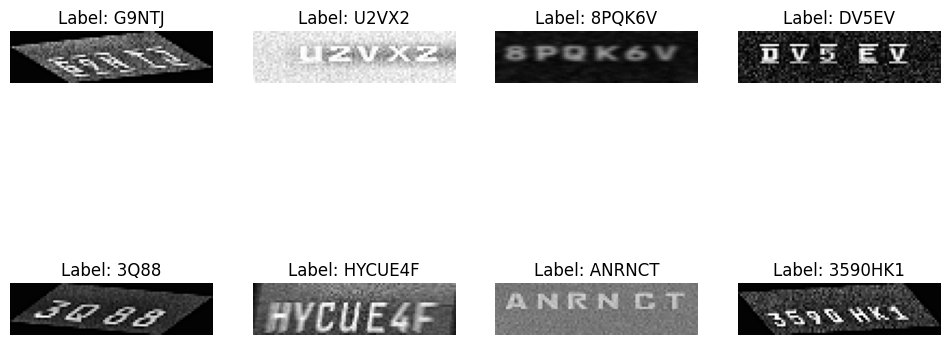

In [7]:
x_batch, y_batch = train_generator[0]

import matplotlib.pyplot as plt
plt.figure(figsize=(12, 6))
for i in range(min(8, len(x_batch))):
    plt.subplot(2, 4, i+1)
    plt.imshow(x_batch[i])
    label = "".join([DECODE_DICT.get(lbl, "") for lbl in y_batch[i].numpy() if lbl in DECODE_DICT])
    plt.title(f"Label: {label}")
    plt.axis('off')

## 5. Model Architecture & Compilation

In [ ]:
model_save_path = os.path.join(MODEL_PATH, MODEL_NAME)

# 1. Import EVERY custom piece of your architecture
from LPRnet.LPRnet_separable import LPRnet, CTCLoss, global_context, small_basic_block

# 2. Map them explicitly so Keras knows exactly what they are
custom_mapping = {
    "LPRnet": LPRnet,
    "CTCLoss": CTCLoss,
    "global_context": global_context,
    "small_basic_block": small_basic_block
}

# === FRESH BUILD with Cosine LR Decay ===
# Building from scratch to reset optimizer state for proper convergence.
# If you want to resume from a checkpoint instead, uncomment the load block.

# --- Option A: Fresh build (RECOMMENDED for retraining) ---
print("Building model from scratch with Cosine LR Decay...")
model = LPRnet()

cosine_decay = tf.keras.optimizers.schedules.CosineDecay(
    initial_learning_rate=LEARNING_RATE,
    decay_steps=EPOCHS * 50,  # 50 steps_per_epoch * 300 epochs
    alpha=LR_MIN              # minimum LR at end of training
)

optimizer = keras.optimizers.Adam(learning_rate=cosine_decay)
model.compile(optimizer=optimizer, loss=CTCLoss)
model.build((1, 24, 94, 3))

# --- Option B: Resume from checkpoint (uncomment if needed) ---
# if os.path.exists(model_save_path):
#     print("Loading existing model...")
#     model = keras.models.load_model(
#         model_save_path,
#         custom_objects=custom_mapping
#     )

model.summary()

## 6. Training Loop

In [ ]:
# === CALLBACKS ===

# 1. Save best model by training loss
checkpoint_cb = tf.keras.callbacks.ModelCheckpoint(
    model_save_path,
    monitor="loss",
    verbose=1,
    save_best_only=True,
    save_weights_only=False,
    mode="min",
    save_freq="epoch",
)

# 2. Reduce LR if loss plateaus for 10 epochs
reduce_lr_cb = tf.keras.callbacks.ReduceLROnPlateau(
    monitor="loss",
    factor=0.5,
    patience=10,
    min_lr=LR_MIN,
    verbose=1
)

# 3. Stop training if no improvement for 30 epochs
early_stop_cb = tf.keras.callbacks.EarlyStopping(
    monitor="loss",
    patience=30,
    restore_best_weights=True,
    verbose=1
)

callbacks = [checkpoint_cb, reduce_lr_cb, early_stop_cb]

print(f"Starting training for {EPOCHS} epochs with Cosine LR Decay...")
print(f"  Initial LR: {LEARNING_RATE}, Min LR: {LR_MIN}")
print(f"  EarlyStopping patience: 30, ReduceLROnPlateau patience: 10")

history = model.fit(
    train_generator,
    epochs=EPOCHS,
    steps_per_epoch=50,
    callbacks=callbacks
)

In [ ]:
# === TRAINING HISTORY VISUALIZATION ===
import matplotlib.pyplot as plt

if 'history' in dir():
    plt.figure(figsize=(12, 5))

    # Plot 1: Loss curve
    plt.subplot(1, 2, 1)
    plt.plot(history.history['loss'], label='Training Loss', color='#2196F3')
    plt.axhline(y=0.3, color='#4CAF50', linestyle='--', label='Target (0.3)')
    plt.axhline(y=0.1, color='#FF9800', linestyle='--', label='Ideal (0.1)')
    plt.xlabel('Epoch')
    plt.ylabel('CTC Loss')
    plt.title('Training Loss Curve')
    plt.legend()
    plt.grid(True, alpha=0.3)

    # Plot 2: LR schedule (if available)
    plt.subplot(1, 2, 2)
    if 'lr' in history.history:
        plt.plot(history.history['lr'], label='Learning Rate', color='#9C27B0')
    else:
        # Reconstruct cosine decay schedule
        import numpy as np
        total_steps = len(history.history['loss']) * 50
        steps = np.arange(0, total_steps, 50)
        lrs = [float(LEARNING_RATE) * 0.5 * (1 + np.cos(np.pi * s / (EPOCHS * 50))) + float(LR_MIN) for s in steps]
        plt.plot(lrs[:len(history.history['loss'])], label='Cosine LR', color='#9C27B0')
    plt.xlabel('Epoch')
    plt.ylabel('Learning Rate')
    plt.title('Learning Rate Schedule')
    plt.legend()
    plt.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig('training_history.png', dpi=150)
    plt.show()

    final_loss = history.history['loss'][-1]
    min_loss = min(history.history['loss'])
    print(f"\nFinal loss: {final_loss:.4f}")
    print(f"Best loss:  {min_loss:.4f}")
    print(f"Epochs completed: {len(history.history['loss'])}")
    if min_loss < 0.3:
        print(">>> PASSED: Loss is below 0.3 target. Model is ready for export!")
    elif min_loss < 0.5:
        print(">>> CLOSE: Loss approaching target. Consider more epochs.")
    else:
        print(">>> WARNING: Loss still high. Model needs more training.")
else:
    print("No training history found. Run the training cell first.")

## 7. Exporting to TFLite
Once training finishes, export the model to `.tflite` format for local deployment in your C# / C++ / Python environments.

In [14]:
import numpy as np

print("Wrapping model in Functional API to lock input shapes...")

# 1. Explicitly define an Input layer with your exact image dimensions
# We use batch_size=1 because TFLite models on edge devices process one image at a time
input_tensor = tf.keras.Input(shape=(24, 94, 3), batch_size=1)

# 2. Pass the input tensor through your existing model
output_tensor = model(input_tensor)

# 3. Create a rigid Functional Model wrapper
functional_model = tf.keras.Model(inputs=input_tensor, outputs=output_tensor)

print("Converting to TFLite...")

# 4. Feed the NEW functional_model into the converter
converter = tf.lite.TFLiteConverter.from_keras_model(functional_model)

# Add standard ops
converter.target_spec.supported_ops = [
    tf.lite.OpsSet.TFLITE_BUILTINS,
    tf.lite.OpsSet.SELECT_TF_OPS
]

# Convert and save
tflite_model = converter.convert()

tflite_file_path = os.path.join(TFLITE_PATH, f"{MODEL_NAME}.tflite")
with open(tflite_file_path, 'wb') as f:
    f.write(tflite_model)

print(f"Successfully exported TFLite model to {tflite_file_path}")

Wrapping model in Functional API to lock input shapes...
Converting to TFLite...
Saved artifact at '/tmp/tmpmr372y80'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(1, 24, 94, 3), dtype=tf.float32, name='keras_tensor_98')
Output Type:
  TensorSpec(shape=(1, 24, 36), dtype=tf.float32, name=None)
Captures:
  135351266078992: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135351266072656: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135351266079184: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135351266081104: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135351266081680: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135351266080144: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135351266079952: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135351266082064: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135351266080336: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135